# Unconstrained Optimization: Maximizing Intermediate Product

This notebook demonstrates GMM and Flow Matching approaches for finding optima by conditioning on derivatives being zero.

**Problem:** Consecutive reactions A → B → C. Find optimal reaction time to maximize intermediate product B.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.5 (main, Jun 11 2025, 15:36:57) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.8


sklearn              1.8.0


torch                2.9.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2026-08-23 10:44:41
Initial memory usage: 300.47 MB


## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching,
    cluster_stats
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Problem: Maximizing Intermediate Product in Consecutive Reactions

Consider consecutive first-order reactions in a batch reactor:
$$A \xrightarrow{k_1} B \xrightarrow{k_2} C$$

where B is the desired product and C is an unwanted byproduct.

**Reactor model:**

The concentration of intermediate B at time $\tau$ is:
$$C_B(\tau) = \frac{C_{A0} k_1}{k_2 - k_1} \left(e^{-k_1\tau} - e^{-k_2\tau}\right)$$

**Optimization problem:**

Find the reaction time $\tau^*$ that maximizes $C_B(\tau)$:
$$\max_{\tau} C_B(\tau)$$

**Optimality condition:**

The first-order optimality condition is:
$$\frac{dC_B}{d\tau} = C_{A0} k_1 \frac{k_2 e^{-k_2\tau} - k_1 e^{-k_1\tau}}{k_2 - k_1} = 0$$

**Analytical solution:**

Solving the optimality condition analytically gives:
$$\tau^* = \frac{\ln(k_1/k_2)}{k_1 - k_2}$$

**Generative approach:**

Instead of solving analytically, we:
1. Generate training data: pairs of $(\tau, C_B, dC_B/d\tau)$
2. Train a generative model on the joint distribution
3. Find the optimum by sampling from $P(\tau | dC_B/d\tau = 0)$

This approach generalizes to problems without analytical solutions.

**Parameters:**
- Rate constant $k_1 = 0.5$ min$^{-1}$ (A → B)
- Rate constant $k_2 = 0.2$ min$^{-1}$ (B → C)
- Initial concentration $C_{A0} = 1.0$ mol/L

In [3]:
# Consecutive reactions: A -> B -> C
# Parameters
k1 = 0.5  # min^-1 (A -> B)
k2 = 0.2  # min^-1 (B -> C)
CA0 = 1.0  # mol/L (initial concentration of A)

# Training/plotting domain for tau.  12 min is about 4 tau*, which covers the
# maximum and its decay while keeping the sampling density near the optimum
# high.  This matches TAU_MAX in make_toc.py so the TOC graphic and Fig. 5
# describe the same model.
TAU_MAX = 12.0  # min

# Analytical optimum
tau_opt_analytical = np.log(k1 / k2) / (k1 - k2)
CB_max_analytical = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_opt_analytical) - np.exp(-k2 * tau_opt_analytical))

print(f"Consecutive Reactions: A → B → C")
print(f"Rate constants: k1={k1} min⁻¹, k2={k2} min⁻¹")
print(f"\nAnalytical optimum:")
print(f"  Optimal reaction time: τ* = {tau_opt_analytical:.3f} min")
print(f"  Maximum CB concentration: {CB_max_analytical:.4f} mol/L")

Consecutive Reactions: A → B → C
Rate constants: k1=0.5 min⁻¹, k2=0.2 min⁻¹

Analytical optimum:
  Optimal reaction time: τ* = 3.054 min
  Maximum CB concentration: 0.5429 mol/L


### Generate Training Data

In [4]:
# Generate data for GMM
tau_gmm = np.linspace(0.1, TAU_MAX, 200)  # reaction time (min)
CB_gmm = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_gmm) - np.exp(-k2 * tau_gmm))
dCB_dtau_gmm = CA0 * k1 * (k2 * np.exp(-k2 * tau_gmm) - k1 * np.exp(-k1 * tau_gmm)) / (k2 - k1)

# Generate data for Flow Matching (with oversampling near optimum)
tau_base = np.linspace(0.1, TAU_MAX, 1000)
tau_near_opt = np.linspace(tau_opt_analytical - 2, tau_opt_analytical + 2, 500)
tau_fm = np.concatenate([tau_base, tau_near_opt])
CB_fm = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_fm) - np.exp(-k2 * tau_fm))
dCB_dtau_fm = CA0 * k1 * (k2 * np.exp(-k2 * tau_fm) - k1 * np.exp(-k1 * tau_fm)) / (k2 - k1)

print(f"GMM training data: {len(tau_gmm)} points")
print(f"FM training data: {len(tau_fm)} points (with oversampling near optimum)")

GMM training data: 200 points
FM training data: 1500 points (with oversampling near optimum)


### Train GMM for Optimization

In [5]:
# Build GMM with τ, CB, and dCB/dτ
data_gmm = np.column_stack([tau_gmm, CB_gmm, dCB_dtau_gmm])

gmm_rxn, info_rxn = best_gmm(data_gmm, verbose=True)
print(f"\nBest GMM: {info_rxn['best_k']} components")

k=1: BIC=-249.3 *
k=2: BIC=-1739.8 *
k=3: BIC=-2288.5 *
k=4: BIC=-2566.2 *
k=5: BIC=-2702.6 *
k=6: BIC=-2798.1 *
k=7: BIC=-2847.7 *
k=8: BIC=-2878.2 *
k=9: BIC=-2898.1 *
k=10: BIC=-2887.9
k=11: BIC=-2875.5
k=12: BIC=-2867.6


k=13: BIC=-2839.8

Best GMM: 9 components


In [6]:
# Find optimum by conditioning on dCB/dτ = 0
c_gmm = gmm_rxn.condition([2], [[0.0]])
samples_gmm = c_gmm.sample(1000)

print(f"GMM Optimization Results:")
print(f"  Mean: {samples_gmm[:, 0].mean():.3f} ± {samples_gmm[:, 0].std():.3f} min")
print(f"  Median: {np.median(samples_gmm[:, 0]):.3f} min")
print(f"  Analytical: {tau_opt_analytical:.3f} min")
print(f"\nCluster statistics:")
cluster_stats(samples_gmm[:, 0])

GMM Optimization Results:
  Mean: 3.010 ± 0.059 min
  Median: 3.022 min
  Analytical: 3.054 min

Cluster statistics:
  0:   3.0095 +/- 0.0588 (n=1000)


### Train Flow Matching for Optimization

In [7]:
# Train Flow Matching: generate τ conditioned on dCB/dτ
x_data_fm = tau_fm.reshape(-1, 1)
c_data_fm = dCB_dtau_fm.reshape(-1, 1)

fm_rxn = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses_rxn = fm_rxn.fit(x_data_fm, c_data_fm, epochs=1000, batch_size=128, verbose=True)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [8]:
# Find optimum by conditioning on dCB/dτ = 0
samples_fm = fm_rxn.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

print(f"Flow Matching Optimization Results:")
print(f"  Mean: {samples_fm[:, 0].mean():.3f} ± {samples_fm[:, 0].std():.3f} min")
print(f"  Median: {np.median(samples_fm[:, 0]):.3f} min")
print(f"  Analytical: {tau_opt_analytical:.3f} min")
print(f"\nCluster statistics:")
cluster_stats(samples_fm[:, 0], eps=0.5)

Flow Matching Optimization Results:
  Mean: 3.044 ± 0.026 min
  Median: 3.046 min
  Analytical: 3.054 min

Cluster statistics:
  0:   3.0444 +/- 0.0255 (n=1000)


---
## Publication Figure: GMM vs Flow Matching Optimization

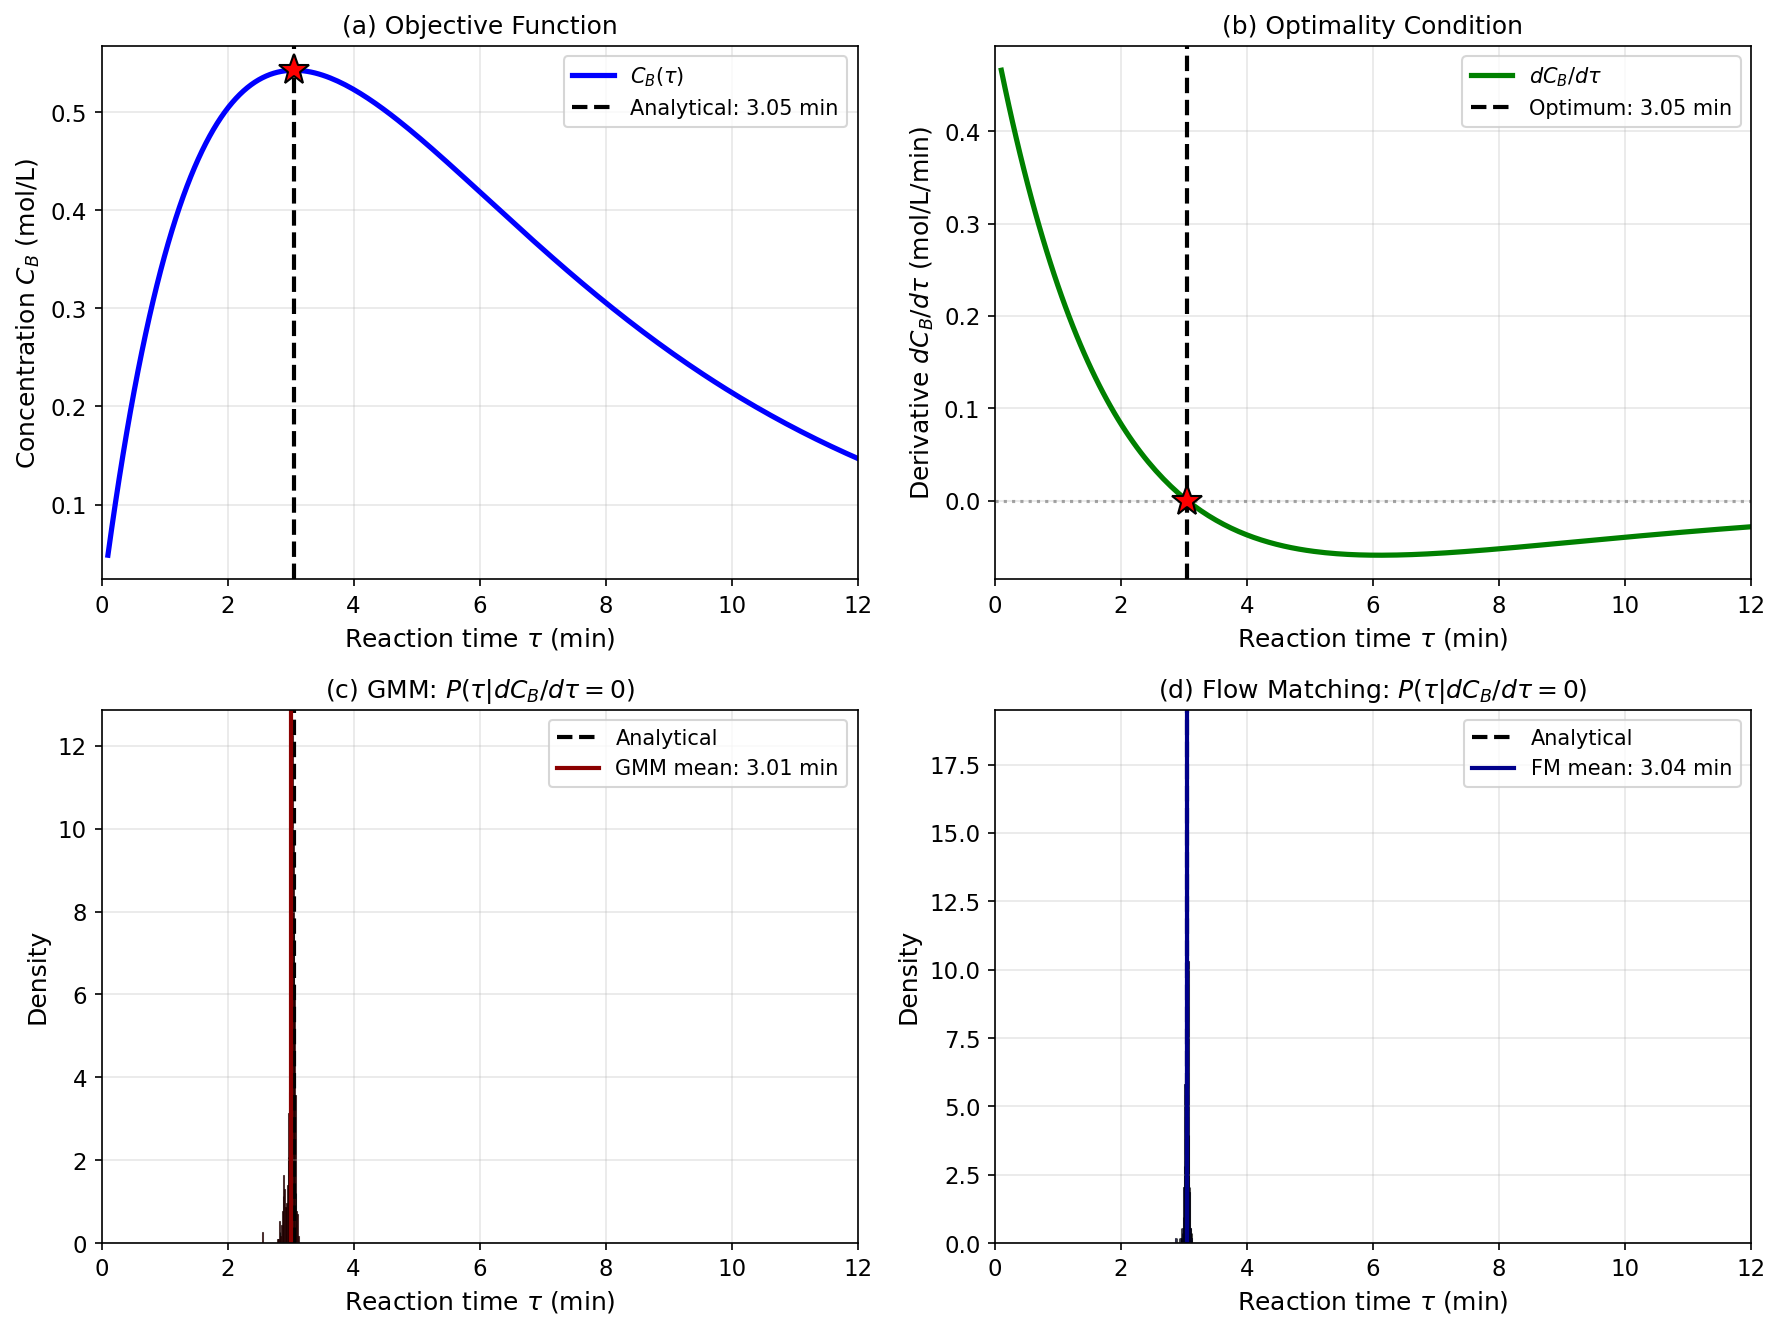


Figure saved as 'optimization_comparison.png'


In [9]:
# Create publication figure: 2x2 grid
# Top row: Objective function and derivative
# Bottom row: GMM and FM distributions

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

tau_plot = np.linspace(0.1, TAU_MAX, 200)
CB_plot = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_plot) - np.exp(-k2 * tau_plot))
dCB_dtau_plot = CA0 * k1 * (k2 * np.exp(-k2 * tau_plot) - k1 * np.exp(-k1 * tau_plot)) / (k2 - k1)

# ============================================================
# Top left: Objective function CB(τ)
# ============================================================
ax = axes[0, 0]
ax.plot(tau_plot, CB_plot, 'b-', lw=2.5, label='$C_B(\\tau)$')
ax.axvline(tau_opt_analytical, color='black', ls='--', lw=2, label=f'Analytical: {tau_opt_analytical:.2f} min')
ax.plot(tau_opt_analytical, CB_max_analytical, 'r*', ms=15, markeredgecolor='black', markeredgewidth=1, zorder=5)
ax.set_xlabel('Reaction time $\\tau$ (min)')
ax.set_ylabel('Concentration $C_B$ (mol/L)')
ax.set_title('(a) Objective Function')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, TAU_MAX)

# ============================================================
# Top right: Derivative dCB/dτ
# ============================================================
ax = axes[0, 1]
ax.plot(tau_plot, dCB_dtau_plot, 'g-', lw=2.5, label="$dC_B/d\\tau$")
ax.axhline(0, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.axvline(tau_opt_analytical, color='black', ls='--', lw=2, label=f'Optimum: {tau_opt_analytical:.2f} min')
ax.plot(tau_opt_analytical, 0, 'r*', ms=15, markeredgecolor='black', markeredgewidth=1, zorder=5)
ax.set_xlabel('Reaction time $\\tau$ (min)')
ax.set_ylabel('Derivative $dC_B/d\\tau$ (mol/L/min)')
ax.set_title('(b) Optimality Condition')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, TAU_MAX)

# ============================================================
# Bottom left: GMM distribution
# ============================================================
ax = axes[1, 0]
ax.hist(samples_gmm[:, 0], bins=50, alpha=0.7, color='red', density=True, edgecolor='black', linewidth=0.5)
ax.axvline(tau_opt_analytical, color='black', ls='--', lw=2, label='Analytical')
ax.axvline(samples_gmm[:, 0].mean(), color='darkred', ls='-', lw=2, label=f'GMM mean: {samples_gmm[:, 0].mean():.2f} min')
ax.set_xlabel('Reaction time $\\tau$ (min)')
ax.set_ylabel('Density')
ax.set_title('(c) GMM: $P(\\tau | dC_B/d\\tau = 0)$')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, TAU_MAX)

# ============================================================
# Bottom right: Flow Matching distribution
# ============================================================
ax = axes[1, 1]
ax.hist(samples_fm[:, 0], bins=50, alpha=0.7, color='blue', density=True, edgecolor='black', linewidth=0.5)
ax.axvline(tau_opt_analytical, color='black', ls='--', lw=2, label='Analytical')
ax.axvline(samples_fm[:, 0].mean(), color='darkblue', ls='-', lw=2, label=f'FM mean: {samples_fm[:, 0].mean():.2f} min')
ax.set_xlabel('Reaction time $\\tau$ (min)')
ax.set_ylabel('Density')
ax.set_title('(d) Flow Matching: $P(\\tau | dC_B/d\\tau = 0)$')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, TAU_MAX)

plt.tight_layout()
plt.savefig('optimization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'optimization_comparison.png'")

### Quantitative Comparison

In [10]:
print("Unconstrained Optimization: Quantitative Comparison")
print("=" * 70)
print(f"Problem: Maximize C_B for consecutive reactions A → B → C")
print(f"Rate constants: k1={k1} min⁻¹, k2={k2} min⁻¹")
print()

print(f"{'Method':<20} {'τ* (mean ± std)':<25} {'C_B max (mol/L)':<20}")
print("-" * 65)

# Analytical
print(f"{'Analytical':<20} {tau_opt_analytical:<25.3f} {CB_max_analytical:<20.4f}")

# GMM
tau_gmm_mean = samples_gmm[:, 0].mean()
tau_gmm_std = samples_gmm[:, 0].std()
CB_gmm = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_gmm_mean) - np.exp(-k2 * tau_gmm_mean))
print(f"{'GMM':<20} {tau_gmm_mean:.3f} ± {tau_gmm_std:.3f}          {CB_gmm:<20.4f}")

# Flow Matching
tau_fm_mean = samples_fm[:, 0].mean()
tau_fm_std = samples_fm[:, 0].std()
CB_fm = (CA0 * k1 / (k2 - k1)) * (np.exp(-k1 * tau_fm_mean) - np.exp(-k2 * tau_fm_mean))
print(f"{'Flow Matching':<20} {tau_fm_mean:.3f} ± {tau_fm_std:.3f}          {CB_fm:<20.4f}")

print()
print("Error analysis:")
print(f"  GMM error:  {abs(tau_gmm_mean - tau_opt_analytical):.4f} min ({100*abs(tau_gmm_mean - tau_opt_analytical)/tau_opt_analytical:.2f}%)")
print(f"  FM error:   {abs(tau_fm_mean - tau_opt_analytical):.4f} min ({100*abs(tau_fm_mean - tau_opt_analytical)/tau_opt_analytical:.2f}%)")

Unconstrained Optimization: Quantitative Comparison
Problem: Maximize C_B for consecutive reactions A → B → C
Rate constants: k1=0.5 min⁻¹, k2=0.2 min⁻¹

Method               τ* (mean ± std)           C_B max (mol/L)     
-----------------------------------------------------------------
Analytical           3.054                     0.5429              
GMM                  3.010 ± 0.059          0.5428              
Flow Matching        3.044 ± 0.026          0.5429              

Error analysis:
  GMM error:  0.0448 min (1.47%)
  FM error:   0.0099 min (0.32%)


### Summary: Unconstrained Optimization

Both GMM and Flow Matching successfully identify the optimal reaction time to maximize intermediate product B by conditioning on the first-order optimality condition $dC_B/d\tau = 0$.

**Key observations:**

1. **Problem structure:** This is a classic chemical engineering optimization—balancing formation of B from A against consumption of B to C. The optimum represents the best trade-off.

2. **Generative approach:** Both methods learn the joint distribution of $(\tau, C_B, dC_B/d\tau)$ from training data, then sample from $P(\tau | dC_B/d\tau = 0)$ to find the optimum.

3. **Accuracy:** Both methods produce narrow distributions centered very close to the analytical optimum (τ* ≈ 3.05 min).

4. **Uncertainty quantification:** The distributions naturally provide confidence intervals around the optimal solution, showing the sensitivity of the optimum to model uncertainty.

5. **Generalizability:** Unlike analytical solutions, this approach works for:
   - Complex reaction networks without closed-form solutions
   - Systems with empirical or tabulated property correlations
   - Multi-objective optimization (by conditioning on multiple gradient components)

**Physical interpretation:**
- **τ < τ*:** Reactor stopped too early, conversion of A to B incomplete
- **τ = τ*:** Optimal operating point, maximum B concentration achieved
- **τ > τ*:** Excessive reaction time, B is being consumed to form unwanted C

This demonstrates that generative models can solve optimization problems through probabilistic inference rather than iterative numerical methods.

In [11]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2026-08-23 10:44:41
End time:        2026-08-23 10:45:01
Elapsed time:    19.31 seconds (0.32 minutes)
----------------------------------------------------------------------
Initial memory:  300.47 MB
Final memory:    534.47 MB
Memory change:   +234.00 MB
